# Context
For the purpose of this notebook, we will simulate being in a company that has recently implented a Advertisement type of marketing strategy to engage more people in the company's products and services. However, using ads for the company's products and services can cost us more compared to psa, that's why our company has been wondering whether or not this type of implementation is effective or not in converting customers compared to our old strategy of exposing people to Public Service Announcements (PSAs). To inspect this, the company has decided to run an experimental test where a certain number of people are exposed to psa, while the other is exposed to ads. To ensure consistency in the study, the company has made sure that the placement of ads and psa is identical, eliminating the positioning factor in determining whether ads is more effective than psa. 

# Goal
Our job as a Data Scientist is to analyze whether or not this ad implementation is better than our original strategy of using public service announcements. We must be able to evaluate the effectiveness of ads relative to psa, which is our baseline. We must also be able to determine the magnitude by which it is more, or less, effective and then, based on our conclusion, recommend actions that the company should take to optimize revenue.

# Method
To achieve our goal, we will conduct A/B Testing, using Ads as our experimental or treatment group, while psa is our control or baseline group. First, we will process the data to fit the input for our analysis, then, determine whether one or the other is more effective, particularly in converting customers. Afterwards, we then determine whether this finding is significant and, if so then, by how much. We may also draw factors that may affect these analysis, such as the number of people engaged with each type of marketing.

# Data
For this simulation, we will utilize a dataset from Kaggle titled "Marketing A/B testing dataset" by FavioVázquez. This dataset contains data regarding user conversion depending on test group. The columns are detailed as follows:

- user id: User ID (unique)
- test group: If "ad" the person saw the advertisement, if "psa" they only saw the public service announcement
- converted: If a person bought the product then True, else is False
- total ads: Amount of ads seen by person
- most ads day: Day that the person saw the biggest amount of ads
- most ads hour: Hour of day that the person saw the biggest amount of ads

# Libraries

In [1]:
import pandas as pd
import sklearn.utils.stats as stats
import os
import numpy as np
from scipy.stats.contingency import chi2_contingency
from scipy.stats import chi2
import seaborn as sns
import matplotlib.pyplot as plt

# Preparing Data

### Downloading Data

In [2]:
os.environ['KAGGLEHUB_CACHE'] = os.curdir

if not os.path.isdir('datasets'):
    import kagglehub
    path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")
else:
    path = os.path.join('datasets','faviovaz','marketing-ab-testing','versions','1')
    
path = os.path.join(path, 'marketing_AB.csv')
print("Path to dataset files:", path)

Path to dataset files: datasets\faviovaz\marketing-ab-testing\versions\1\marketing_AB.csv


### Inspecting Data

In [3]:
df = pd.read_csv(path).drop('Unnamed: 0', axis = 1)
df

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...
588096,1278437,ad,False,1,Tuesday,23
588097,1327975,ad,False,1,Tuesday,23
588098,1038442,ad,False,3,Tuesday,23
588099,1496395,ad,False,1,Tuesday,23


In [4]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [5]:
df[['test group','converted']].sample(10)

,test group,converted
378245,ad,False
84750,ad,False
50094,ad,False
32254,ad,False
428401,ad,False
109409,ad,False
174564,ad,False
286090,ad,False
226030,ad,False
452966,ad,False


In [6]:
df['most ads hour'].value_counts()

most ads hour
13    47655
12    47298
11    46210
14    45648
15    44683
10    38939
16    37567
17    34988
18    32323
9     31004
19    30352
21    29976
20    28923
22    26432
23    20166
8     17627
7      6405
0      5536
2      5333
1      4802
3      2679
6      2068
5       765
4       722
Name: count, dtype: int64

# Hypothesis Testing

- Null Hypothesis = There is no significant change
- Alternative Hypothesis = There is a significant change

In [7]:
grouped_df = df.groupby('test group').agg({'converted':'sum', 'user id':'count','total ads':'sum', 'most ads hour':'mean'})
grouped_df

,converted,user id,total ads,most ads hour
test group,,,,
ad,14423,564577,14014701,14.475900
psa,420,23524,582481,14.304923


In [8]:
grouped_df['conversion rate'] = grouped_df['converted']/grouped_df['user id']
grouped_df

,converted,user id,total ads,most ads hour,conversion rate
test group,,,,,
ad,14423,564577,14014701,14.475900,0.025547
psa,420,23524,582481,14.304923,0.017854


In [9]:
contingency_table = pd.crosstab(df['test group'], df['converted'])
contingency_table

converted,False,True
test group,,
ad,550154,14423
psa,23104,420


In [10]:
chi2, p, dof, expected = chi2_contingency(contingency_table)
p

np.float64(1.9989623063390075e-13)

In [11]:
alpha = 0.05

print('There is a significant difference' if alpha > p else 'There is not enough evidence')

There is a significant difference


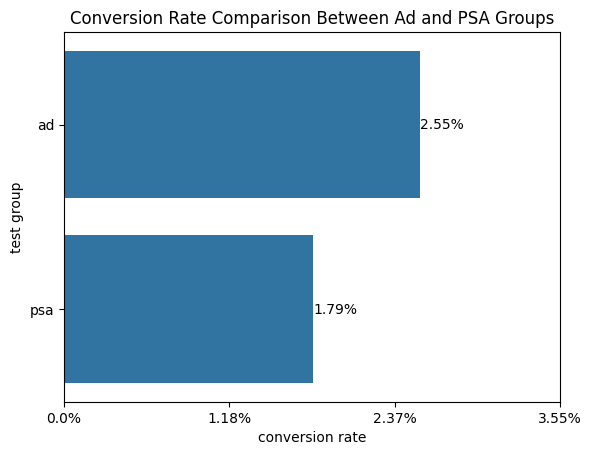

In [12]:
gap = 0.01
upper_limit = max(grouped_df['conversion rate']) + gap
lower_limit = 0
xticks = np.linspace(lower_limit, upper_limit, num = 4)

# Without error bars
bars = sns.barplot(grouped_df['conversion rate'], orient = 'h')
plt.xticks(xticks, labels = [f'{round(x*100, 2)}%' for x in xticks])
plt.bar_label(bars.containers[0], labels = [f'{round(x*100, 2)}%' for x in grouped_df['conversion rate']])
plt.title('Conversion Rate Comparison Between Ad and PSA Groups')
plt.show()

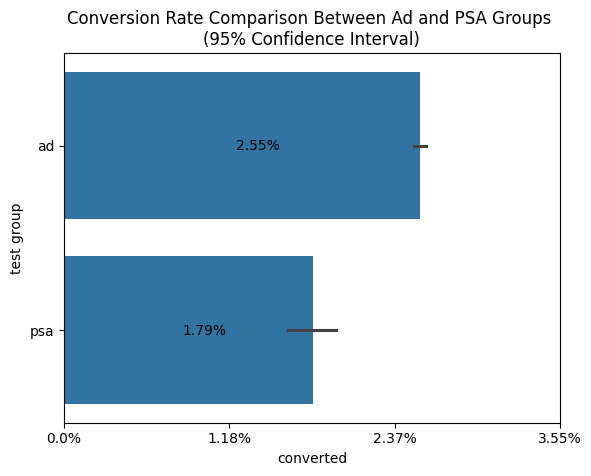

In [13]:
# With error bars
sns.barplot(data = df, y = "test group", x = "converted", orient = 'h', errorbar = ('ci', 95))
plt.xticks(xticks, labels = [f'{round(x*100, 2)}%' for x in xticks])
plt.bar_label(bars.containers[0], labels = [f'{round(x*100, 2)}%' for x in grouped_df['conversion rate']], label_type = 'center')
plt.title('Conversion Rate Comparison Between Ad and PSA Groups \n(95% Confidence Interval)')
plt.show()

# TO STUDY THEN ADD


## Experiment Design
- Metric: Conversion (0/1)
- Groups: Ad vs PSA
- Test: Two-proportion comparison

Although statistically significant, the lift is only +0.8%, which may not justify increased ad spend.

## Limitations
- No randomization validation
- Possible time-based bias (most ads hour)
- No control for user heterogeneity

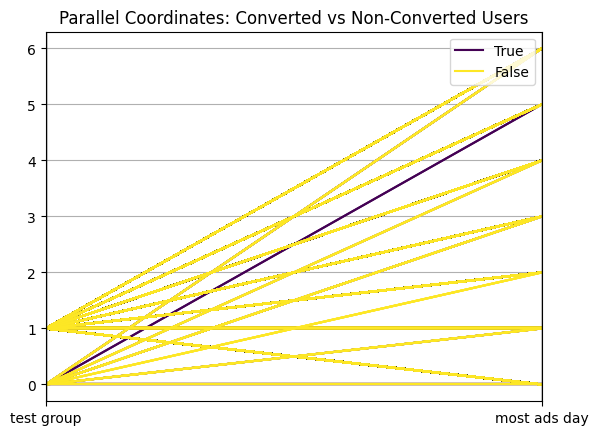

In [14]:
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt

n_samples = 2000

# Prepare data
plot_df = df.copy()

plot_df['test group'] = plot_df['test group'].map({'ad': 1, 'psa': 0})
plot_df['most ads day'] = plot_df['most ads day'].map({'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 
                                                       'Friday': 4, 'Saturday': 5, 'Sunday': 6})
plot_df = plot_df.drop('user id', axis = 1) # irrelevant

# Comment as fits
plot_df = plot_df.drop('total ads', axis = 1) # This messes with the y-scale, causing other features to be hardly noticed
plot_df = plot_df.drop('most ads hour', axis = 1) # Just to make visualization easier

# Stratification
converted_df = plot_df.loc[plot_df['converted'] == True, :]
non_converted_df = plot_df.loc[plot_df['converted'] == False, :]

combined_samples = pd.concat([
    converted_df.sample(n_samples//2),
    non_converted_df.sample(n_samples//2)
], axis = 0)

plt.figure()
parallel_coordinates(
    combined_samples,
    class_column='converted',
    colormap = 'viridis'
)
plt.title("Parallel Coordinates: Converted vs Non-Converted Users")
plt.show()

In [15]:
combined_samples['converted'].value_counts()

converted
True     1000
False    1000
Name: count, dtype: int64

In [16]:
combined_samples

,test group,converted,most ads day
62849,1,True,0
8414,1,True,2
121831,1,True,5
275326,1,True,0
218216,1,True,4
...,...,...,...
38001,1,False,4
462358,1,False,3
524428,1,False,1
345187,1,False,1


In [24]:
# get lift
ad_conv = grouped_df['conversion rate']['ad']
psa_conv = grouped_df['conversion rate']['psa']

lift = (ad_conv - psa_conv)/psa_conv
print(lift)

0.43085064022225833
